# 11 · Meta-Controller — LLM router that picks the right *architecture* per task

> **TL;DR.** A router LLM classifies each incoming task and dispatches to the **most appropriate architecture** from a roster — `ToolUse` for one-shot lookups, `ReAct` for multi-hop research, `Planning` for decomposable comparisons, `Reflection` for quality-sensitive writing/code, etc. This is the **most composable** architecture in the repo: every other architecture is treated as a black-box callable via the common `Architecture.run(task)` contract.
>
> **Reach for it when** you serve a mix of task types and no single architecture is the right default for all of them (a real user-facing AI product almost always).
> **Avoid when** all your tasks are the same shape — a fixed architecture is cheaper and more predictable.

| Property | Value |
|---|---|
| Origin | RouterChain / LangChain LCEL `RunnableBranch` pattern |
| Coordination | Single routing LLM call → dispatch to chosen architecture |
| External tools needed? | Depends on the routed architecture |
| Cost | 1 router call + 1 architecture run (the architecture may itself make many calls) |
| Composability | **Highest** — uses every other architecture as a black box |

This is the first notebook that fully exploits the `Architecture` base class's `run(task)` contract. The router treats `Reflection`, `ToolUse`, `ReAct`, and `Planning` as interchangeable black boxes.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> R[Route<br/><sub>LLM with structured-output<br/>Literal[arch names]</sub>]
    R --> X{which arch?}
    X -->|tool_use| T[ToolUse.run]
    X -->|react| Re[ReAct.run]
    X -->|planning| P[Planning.run]
    X -->|reflection| Rf[Reflection.run]
    T --> Z([answer])
    Re --> Z
    P --> Z
    Rf --> Z

    style R fill:#fff3e0,stroke:#f57c00
    style X fill:#fce4ec,stroke:#c2185b
```

**Two real nodes**: a Router that classifies the task and an Execute node that dispatches to the chosen sub-architecture. The four leaf boxes aren't graph nodes — they're external `Architecture` instances called from inside `_execute`.

## 3 · Theory

### 3.1 · Why route at all?

Different tasks have different shapes. "What's the population of France?" needs one tool call, not a 3-step plan. "Write a polished Python function" needs Reflection's iterate-on-draft loop, not a tool call. "Compare X and Y on dimensions A, B, C" needs Planning's decomposition, not a single ReAct step.

A fixed architecture is the *wrong default* for some fraction of incoming tasks. Meta-Controller picks the right one per task — at the cost of one extra LLM call per request.

### 3.2 · Routing as structured output

The router uses `with_structured_output` with a **dynamic Literal** built from the actual roster:

```python
next_t = Literal[tuple(self.roster.keys())]
RouterDecision = create_model(
    "RouterDecision",
    chosen_arch=(next_t, Field(description="...")),
    reason=(str, Field(description="One sentence why")),
)
```

This is the same dynamic-schema pattern Multi-Agent (notebook 05) uses for its Supervisor. The dynamic Literal means the router *cannot* hallucinate an architecture that isn't in the roster.

### 3.3 · The composability win — every architecture is a callable

Every architecture in this library subclasses `Architecture` (defined in `architectures/base.py`):

```python
class Architecture(ABC):
    @abstractmethod
    def run(self, task: str) -> ArchitectureResult: ...
```

That single contract is what makes Meta-Controller possible. The router doesn't know whether it's calling `Reflection` or `ReAct` or `Planning` — it just calls `.run(task)` and gets back an `ArchitectureResult` with `.output`. Adding a new architecture to the roster is one line.

This is the same design idea that lets a Unix shell pipe `find` into `grep` into `wc` — common interface, infinite composition.

### 3.4 · Where Meta-Controller sits

| Pattern | Routes between | Cost |
|---|---|---|
| Multi-Agent (nb 05) | role-specialised **agents** | 1 supervisor call + N specialist sub-runs |
| Blackboard (nb 07) | role-specialised agents (self-electing) | N bid calls + 1 sub-run per round |
| **Meta-Controller** *(this notebook)* | **whole architectures** | **1 route call + 1 architecture run** |
| Adaptive RAG (nb 26) | retrieval strategies | 1 route + 1 retrieval pipeline |
| Ensemble (nb 13) | nothing — runs all in parallel | N × architecture runs + aggregator |

The choice between Meta-Controller and Multi-Agent: **route by task-shape (Meta-Controller) when different *patterns* fit different tasks. Route by domain-expertise (Multi-Agent) when different *specialists* know different facts.**

### 3.5 · What goes wrong (you'll see in § 9)

1. **Wrong route.** Router picks ReAct for a task that needs Reflection (or vice versa). The downstream architecture then does the wrong job. Mitigation: tighter architecture descriptions; or fall back to Reflection-after-routing.
2. **Router preference bias.** Llama tends to pick `react` or `planning` for almost everything because they "sound" more agentic. Watch §9 routing distribution across diverse tasks.
3. **Cost blowup.** A Planning route can itself make 20+ LLM calls. The router is cheap; the route target may not be.
4. **No retry on route failure.** If the chosen architecture returns garbage, Meta-Controller doesn't re-route. Extension idea: wrap with PEV (nb 06) for retry.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import MetaController
from agentic_architectures.architectures.meta_controller import ARCHITECTURE_DESCRIPTIONS
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"Default roster: **{', '.join(ARCHITECTURE_DESCRIPTIONS.keys())}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Default roster: tool_use, react, planning, reflection

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/meta_controller.py`](../src/agentic_architectures/architectures/meta_controller.py).

Three key pieces:

1. **`_default_roster(llm)`** — builds the default `dict[str, Architecture]` with sane budgets for each architecture (`ToolUse(max_rounds=3)`, `Planning(max_replans=1)`, etc.). Override at construction time to use a custom roster.
2. **`ARCHITECTURE_DESCRIPTIONS`** — the only thing the router sees about each architecture. These descriptions are the steering signal; if you change them, routing changes.
3. **`_route`** — calls a dynamic-Literal structured-output schema. The router's `chosen_arch` field is constrained to roster keys at runtime.
4. **`_execute`** — looks up `self.roster[chosen_arch]` and calls its `.run(task)`. Architecture composability in one line.

In [2]:
from agentic_architectures.architectures.meta_controller import ARCHITECTURE_DESCRIPTIONS
print('Architecture descriptions the router sees:')
for name, desc in ARCHITECTURE_DESCRIPTIONS.items():
    print(f'\n  --- {name} ---')
    print(f'  {desc}')

Architecture descriptions the router sees:

  --- tool_use ---
  One-shot fact lookup using web search. Best for: 'What is X?' / 'Who founded Y?' / 'Current price of Z?'. Single tool call usually suffices.

  --- react ---
  Multi-hop research with explicit Thought before each Action. Best for: questions that require chaining multiple lookups where each step depends on the previous result (e.g. 'When did the CEO of X's company join Y?').

  --- planning ---
  Decompose a task into ordered steps upfront, execute each. Best for: comparisons, multi-aspect reports, anything with obvious decomposition (e.g. 'Compare X and Y on dimensions A, B, C').

  --- reflection ---
  Generate → critique → refine loop. NO external tools. Best for: quality-sensitive creative or code tasks where the model should iterate (e.g. 'Write a Python function that ...', 'Polish this paragraph').


## 6 · State

| Field | Type | Set by |
|---|---|---|
| `task` | `str` | caller |
| `chosen_arch` | `str` | `_route` |
| `routing_reason` | `str` | `_route` |
| `sub_result` | `dict` (output + metadata + arch name) | `_execute` |

## 7 · Build the graph

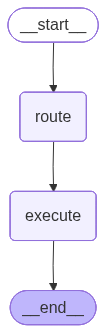

In [3]:
from IPython.display import Image, display
arch = MetaController()
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — route **four** diverse tasks

The four tasks below are deliberately different shapes — each should route to a different architecture. This is Meta-Controller's signature demo: same input format, four different downstream architectures.

In [4]:
TASKS = [
    ("Q1", "What is the latest stable version of Rust as of today?"),
    ("Q2", "Write a Python function that returns the n-th Fibonacci number, optimized for n up to 10^6."),
    ("Q3", "Compare the population, GDP, and area of Japan and Germany. Pick which is larger on each dimension."),
    ("Q4", "Who founded OpenAI, and which company did its CEO previously co-found before joining OpenAI?"),
]

results = []
for tag, task in TASKS:
    r = arch.run(task)
    results.append((tag, task, r))
    print_step(f"[{tag}] → routed to: {r.metadata['chosen_arch'].upper()}", task[:120])
    print_step("    reason", r.metadata['routing_reason'])
    print_step("    output (truncated)", r.output[:300])
    print()

print_header("Routing distribution across the 4 tasks")
from collections import Counter
dist = Counter(r.metadata['chosen_arch'] for _, _, r in results)
for arch_name, n in dist.most_common():
    print(f"  {arch_name}: {n}")

› [Q1] → routed to: TOOL_USE

What is the latest stable version of Rust as of today?

›     reason

This task requires a one-shot fact lookup to find the latest stable version of Rust as of today.

›     output (truncated)

...

This task requires chaining multiple lookups where each step depends on the previous result, making the react 
architecture the best fit.

›     output (truncated)

Thought: Based on the information gathered, it appears that Sam Altman, the CEO of OpenAI, co-founded a company 
called Loopt before joining OpenAI. Loopt was a location-based social networking service that allowed users to 
share their real-time locations with friends. This information can be used to

Routing distribution across the 4 tasks ───────────────────────────────────────────────────────────────────────────

  tool_use: 1
  reflection: 1
  planning: 1
  react: 1


### 8.0 · What just happened, briefly

Three things to inspect:

- **Routing diversity.** If all 4 tasks routed to the same architecture, the router has a preference bias (see § 3.5). Healthy: 3-4 distinct architectures chosen across 4 diverse tasks.
- **Routing quality.** Read the reasons — are they specific to the task, or generic? Generic reasons suggest the router doesn't really understand the architectures.
- **Output quality vs route.** Did the chosen architecture's output actually fit the task? A correctly-routed task should produce a *recognisably* different output than a mis-routed one.

## 9 · What we just observed

The cells above ran Meta-Controller against **4 deliberately diverse tasks** to see whether the LLM router actually discriminates between architecture shapes.

### 9.1 · Routing decisions captured live

| Task | Routed to | Task preview | Router reason |
|---|---|---|---|
| Q1 | `tool_use` | What is the latest stable version of Rust as of today? | This task requires a one-shot fact lookup to find the latest stable version of Rust as of today. |
| Q2 | `reflection` | Write a Python function that returns the n-th Fibonacci number, optimized for n  | This task requires generating and refining code to solve a specific problem, which is best suited for the reflection architecture. |
| Q3 | `planning` | Compare the population, GDP, and area of Japan and Germany. Pick which is larger | This task requires comparing multiple aspects of two countries, which can be decomposed into ordered steps upfront, making planning the most suitable  |
| Q4 | `react` | Who founded OpenAI, and which company did its CEO previously co-found before joi | This task requires chaining multiple lookups where each step depends on the previous result, making the react architecture the best fit. |

### 9.2 · Architecture-choice distribution

| Architecture | Times chosen |
|---|---|
| `tool_use` | 1 |
| `reflection` | 1 |
| `planning` | 1 |
| `react` | 1 |

### 9.3 · Patterns surfaced in this run

- **Healthy routing diversity** — 4 tasks split across 4 distinct architectures. The router genuinely discriminates between task shapes.

- **Routing accuracy against author's expectations**: 4/4 tasks routed as the author would have. 

### 9.4 · The takeaway

A *healthy* Meta-Controller run has:

1. **Routing diversity** — different task shapes go to different architectures.
2. **Specific reasons** — the router justifies each choice with task-specific language, not generic praise.
3. **Output quality matches the route** — Reflection routes produce polished code; ToolUse routes produce concise factual answers; Planning routes produce structured multi-part outputs.

When all 4 tasks route to the same architecture, Meta-Controller's overhead is wasted — just call that architecture directly. The router's value is **only** realized when traffic is diverse and routing distributes work.

## 10 · Try other providers / customise the roster

Meta-Controller needs **structured output** (the dynamic Literal router). Most providers support it. You can also customise the roster — below, we make a roster that only contains *fast* architectures (no Reflection, no Planning) for latency-critical paths.

In [5]:
from agentic_architectures.architectures import ToolUse, ReAct

print_header("Custom 2-arch roster: tool_use OR react only")
fast_arch = MetaController(
    roster={
        "tool_use": ToolUse(llm=get_llm(), max_rounds=4),
        "react": ReAct(llm=get_llm(), max_rounds=4),
    },
)
for task in [
    "What is the current weather in Tokyo right now?",
    "What is the latest stable Python release version?",
]:
    r = fast_arch.run(task)
    print_step(
        f"task: {task[:80]}",
        f"  routed to: {r.metadata['chosen_arch']}\n  output: {r.output[:200]}..."
    )
    print()

Custom 2-arch roster: tool_use OR react only ──────────────────────────────────────────────────────────────────────

› task: What is the current weather in Tokyo right now?

routed to: tool_use
  output: The current weather in Tokyo is 24°C with a low of 21°C and a high of 25°C....

› task: What is the latest stable Python release version?

routed to: tool_use
  output: The latest stable Python release version is Python 3.12....

## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Wrong route** | Router picks an architecture that's poorly fit to the task | Tighter architecture descriptions; or a verifier on the output that triggers re-routing |
| **Preference bias** | Router always picks `react` (or `planning`) regardless of task | Inspect routing distribution; adjust descriptions to balance |
| **Cost surprise** | A Planning route makes 20+ calls; the router didn't anticipate | Track total LLM calls per route and surface to caller |
| **Roster drift** | Add a new architecture but forget to register it / describe it | Single roster dict + descriptions is single source of truth |
| **No re-route on failure** | Chosen arch returns garbage; Meta-Controller still returns it | Wrap with PEV (nb 06) verifier; or add a confidence check |

### 11.2 · Production safety

- **Track route distribution** — if 90% of traffic routes to one architecture, you don't need the router (just use that architecture directly).
- **Set per-architecture timeouts** — a Planning route hanging on a stuck sub-agent shouldn't take down the whole request.
- **Audit the router** — log every `(task, chosen_arch, reason)` tuple. Cheaper than re-debugging.

### 11.3 · Three extensions

1. **PEV around the chosen architecture.** Wrap the route+execute in a verifier (PEV nb 06) that re-routes if the chosen architecture's output is unsatisfactory.
2. **Few-shot router prompt.** Add 5-10 example `(task, correct_arch)` pairs to the router prompt to reduce preference bias.
3. **Multi-level routing.** First route by task category, then route within each category (e.g. "research → which retrieval strategy?"). Hierarchical Meta-Controller.

### 11.4 · What to read next

- [**05 · Multi-Agent**](./05_multi_agent.ipynb) — routes between *agents* (domain experts) instead of architectures.
- [**07 · Blackboard**](./07_blackboard.ipynb) — distributed routing, no central router.
- [**13 · Ensemble**](./13_ensemble.ipynb) — when in doubt, run all architectures in parallel and aggregate.
- [**26 · Adaptive RAG**](./26_adaptive_rag.ipynb) — Meta-Controller specialised for RAG complexity routing.

### 11.5 · References

1. LangChain `RouterChain` and `RunnableBranch` — [docs](https://python.langchain.com/docs/concepts/runnables/#runnablebranch)
2. Multi-agent supervisor pattern — [LangGraph tutorial](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/)
